In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

print("All imports done")

All imports done


In [2]:
posts    = pd.read_csv("reddit_data_clean/posts_clean.csv")
comments = pd.read_csv("reddit_data_clean/comments_clean.csv")

comments = comments.rename(columns={"body": "text"})

posts_df    = posts[["subreddit", "text"]].copy()
comments_df = comments[["subreddit", "text"]].copy()

posts_df["source"]    = "post"
comments_df["source"] = "comment"

df = pd.concat([posts_df, comments_df], ignore_index=True)

df = df.dropna(subset=["text"])
df = df[df["text"].str.strip().str.len() > 0]
df = df.reset_index(drop=True)

print(f"Total rows: {len(df)}")
print(f"\nRows per subreddit:")
print(df["subreddit"].value_counts())

Total rows: 28320

Rows per subreddit:
subreddit
relationship_advice    2969
gaming                 2933
AskReddit              2914
AITAH                  2894
mumbai                 2879
cats                   2829
Fitness                2797
depression             2754
Btechtards             2716
JEENEETards            2635
Name: count, dtype: int64


In [3]:
HINGLISH_STOPWORDS = {
    "hai", "hain", "tha", "thi", "the", "hoga", "hogi",
    "nahi", "nah", "nai", "na", "mat",
    "kya", "kyu", "kyun", "kyunki", "kaise", "kab", "kahan", "kaun",
    "aur", "ya", "lekin", "par", "toh", "to", "ki", "ka", "ke", "ko",
    "se", "mein", "pe", "tak", "bhi", "hi", "sirf", "bas",
    "main", "mujhe", "mera", "meri", "mere", "hum", "humara",
    "tu", "tum", "tumhara", "aap", "apna", "apni", "apne",
    "yeh", "ye", "woh", "wo", "iska", "uska", "inka", "unka",
    "ek", "do", "teen", "bahut", "thoda", "zyada", "kam",
    "accha", "theek", "sahi", "galat", "achha", "acha",
}

FILLER_WORDS = {
    "get", "got", "getting", "said", "say", "saying", "says",
    "go", "going", "went", "gone", "come", "came", "coming",  
    "use", "used", "using", "see", "saw", "seen", "seeing",
    "look", "looked", "looking", "could", "can", "would", "should", "might", "must",
    "take", "took", "taken", "taking", "put", "putting","told",
    "give", "gave", "given", "giving", "keep", "kept", "keeping",
    "let", "letting", "need", "needed", "needing", 
    "seem", "seemed", "seeming",
    "thing", "things", "something", "anything", "everything", "nothing",
    "way",  "lot", "bit",
}

STOPWORDS = set(stopwords.words("english")) | {
    "reddit", "www", "http", "https", "com", "amp", "gt", "like", "just", "get", "say", "go", "make", "know", "think", "want", "use", "see", "come"
} | HINGLISH_STOPWORDS | FILLER_WORDS

In [4]:
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w.isalpha() and w not in STOPWORDS and len(w) > 2
    ]
    return " ".join(tokens)

print("Preprocessing text — this may take a minute...")
df["text_clean"] = df["text"].apply(preprocess)

df = df[df["text_clean"].str.strip().str.len() > 0].reset_index(drop=True)

print(f"Done. Rows remaining: {len(df)}")
print(f"\nSample:")
print(df[["subreddit", "text_clean"]].head(3))

Preprocessing text — this may take a minute...
Done. Rows remaining: 28128

Sample:
  subreddit                                         text_clean
0      cats  year together end stand dusty turned may bring...
1      cats   found sweet baby parking located owner yet gerry
2      cats  cosmo cosmo long still blow mind back older pi...


In [5]:
X = df["text_clean"]
y = df["subreddit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nTF-IDF matrix shape: {X_train_tfidf.shape}")

Training samples: 22502
Test samples:     5626

TF-IDF matrix shape: (22502, 10000)


In [6]:
clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf.fit(X_train_tfidf, y_train)

y_pred = clf.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6413

Classification Report:
                     precision    recall  f1-score   support

              AITAH       0.79      0.66      0.72       578
          AskReddit       0.58      0.64      0.61       581
         Btechtards       0.57      0.50      0.53       538
            Fitness       0.84      0.81      0.83       559
        JEENEETards       0.56      0.52      0.54       522
               cats       0.71      0.71      0.71       554
         depression       0.66      0.72      0.69       549
             gaming       0.59      0.60      0.59       581
             mumbai       0.52      0.58      0.55       571
relationship_advice       0.63      0.67      0.65       593

           accuracy                           0.64      5626
          macro avg       0.65      0.64      0.64      5626
       weighted avg       0.65      0.64      0.64      5626



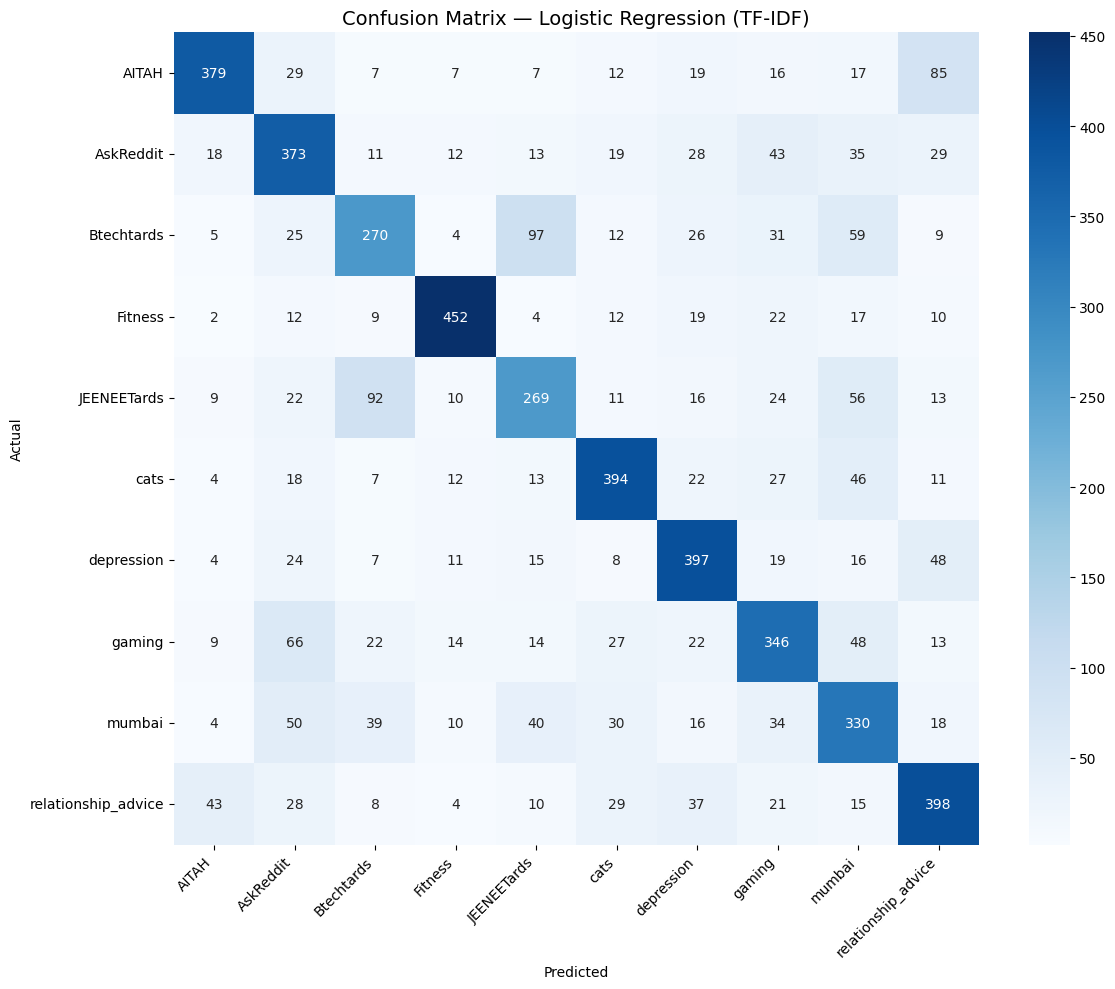

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_,
            yticklabels=clf.classes_,
            ax=ax)

ax.set_title("Confusion Matrix — Logistic Regression (TF-IDF)", fontsize=14)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

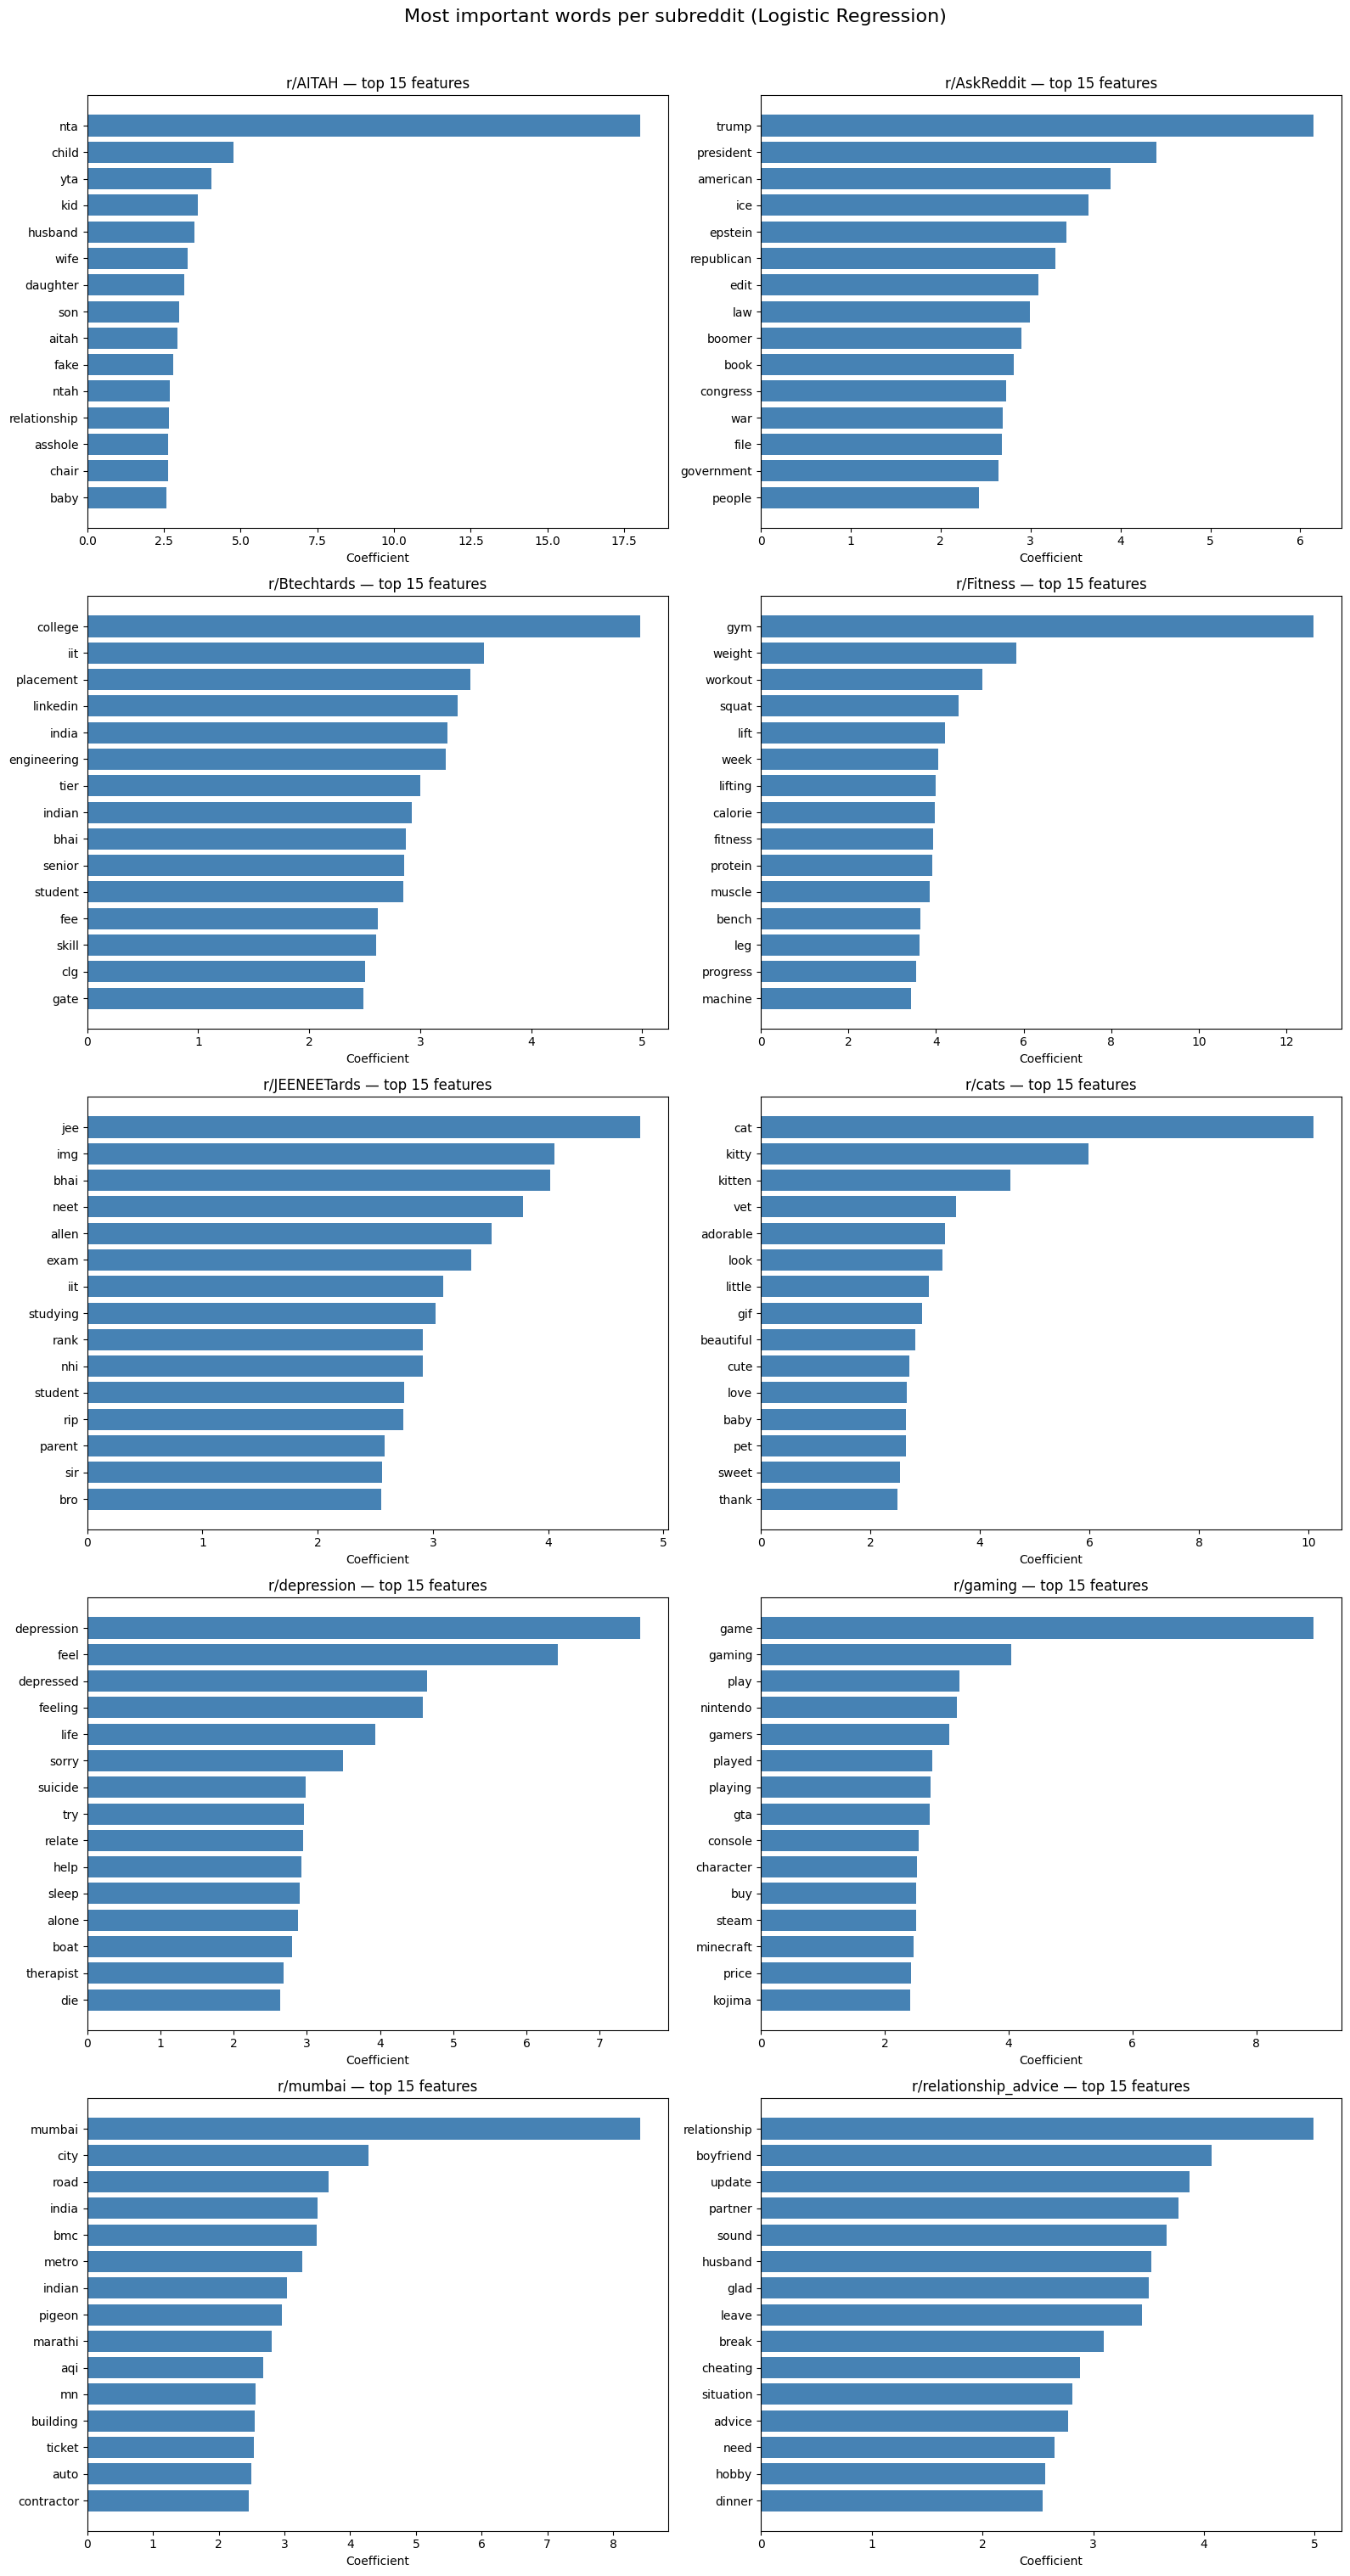

In [8]:
feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(5, 2, figsize=(16, 30))
axes = axes.flatten()

for i, subreddit in enumerate(clf.classes_):
    coefs = clf.coef_[i]
    top_indices = np.argsort(coefs)[-15:]
    top_features = feature_names[top_indices]
    top_scores   = coefs[top_indices]

    axes[i].barh(top_features, top_scores, color="steelblue")
    axes[i].set_title(f"r/{subreddit} — top 15 features")
    axes[i].set_xlabel("Coefficient")

fig.suptitle("Most important words per subreddit (Logistic Regression)", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("top_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
from bertopic import BERTopic

docs = df["text_clean"].tolist()
labels = df["subreddit"].tolist()

topic_model = BERTopic(language="english", calculate_probabilities=True, verbose=True)
topics, probs = topic_model.fit_transform(docs)

df["topic"] = topics

print(f"Number of topics found: {topic_model.nr_topics}")
print(f"\nTopic info:")
print(topic_model.get_topic_info().head(20))

2026-04-20 00:23:06,568 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/879 [00:00<?, ?it/s]

2026-04-20 00:24:30,575 - BERTopic - Embedding - Completed ✓
2026-04-20 00:24:30,575 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-20 00:24:56,478 - BERTopic - Dimensionality - Completed ✓
2026-04-20 00:24:56,482 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-20 00:28:21,016 - BERTopic - Cluster - Completed ✓
2026-04-20 00:28:21,033 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-20 00:28:22,182 - BERTopic - Representation - Completed ✓


Number of topics found: None

Topic info:
    Topic  Count                                          Name  \
0      -1  13208                      -1_life_kid_child_family   
1       0   2089                      0_gym_weight_set_workout   
2       1    966                        1_cat_kitty_kitten_vet   
3       2    737                           2_bhai_nhi_kar_kuch   
4       3    496                     3_game_steam_gaming_price   
5       4    295                   4_mumbai_city_metro_stadium   
6       5    258            5_nta_consequence_handled_business   
7       6    252                          6_nta_kid_child_baby   
8       7    245               7_india_marathi_indian_gujarati   
9       8    231                       8_click_nhi_college_koi   
10      9    214             9_college_internship_tier_student   
11     10    190           10_trump_republican_president_voted   
12     11    176                    11_sleep_wake_bed_sleeping   
13     12    147  12_depression_de

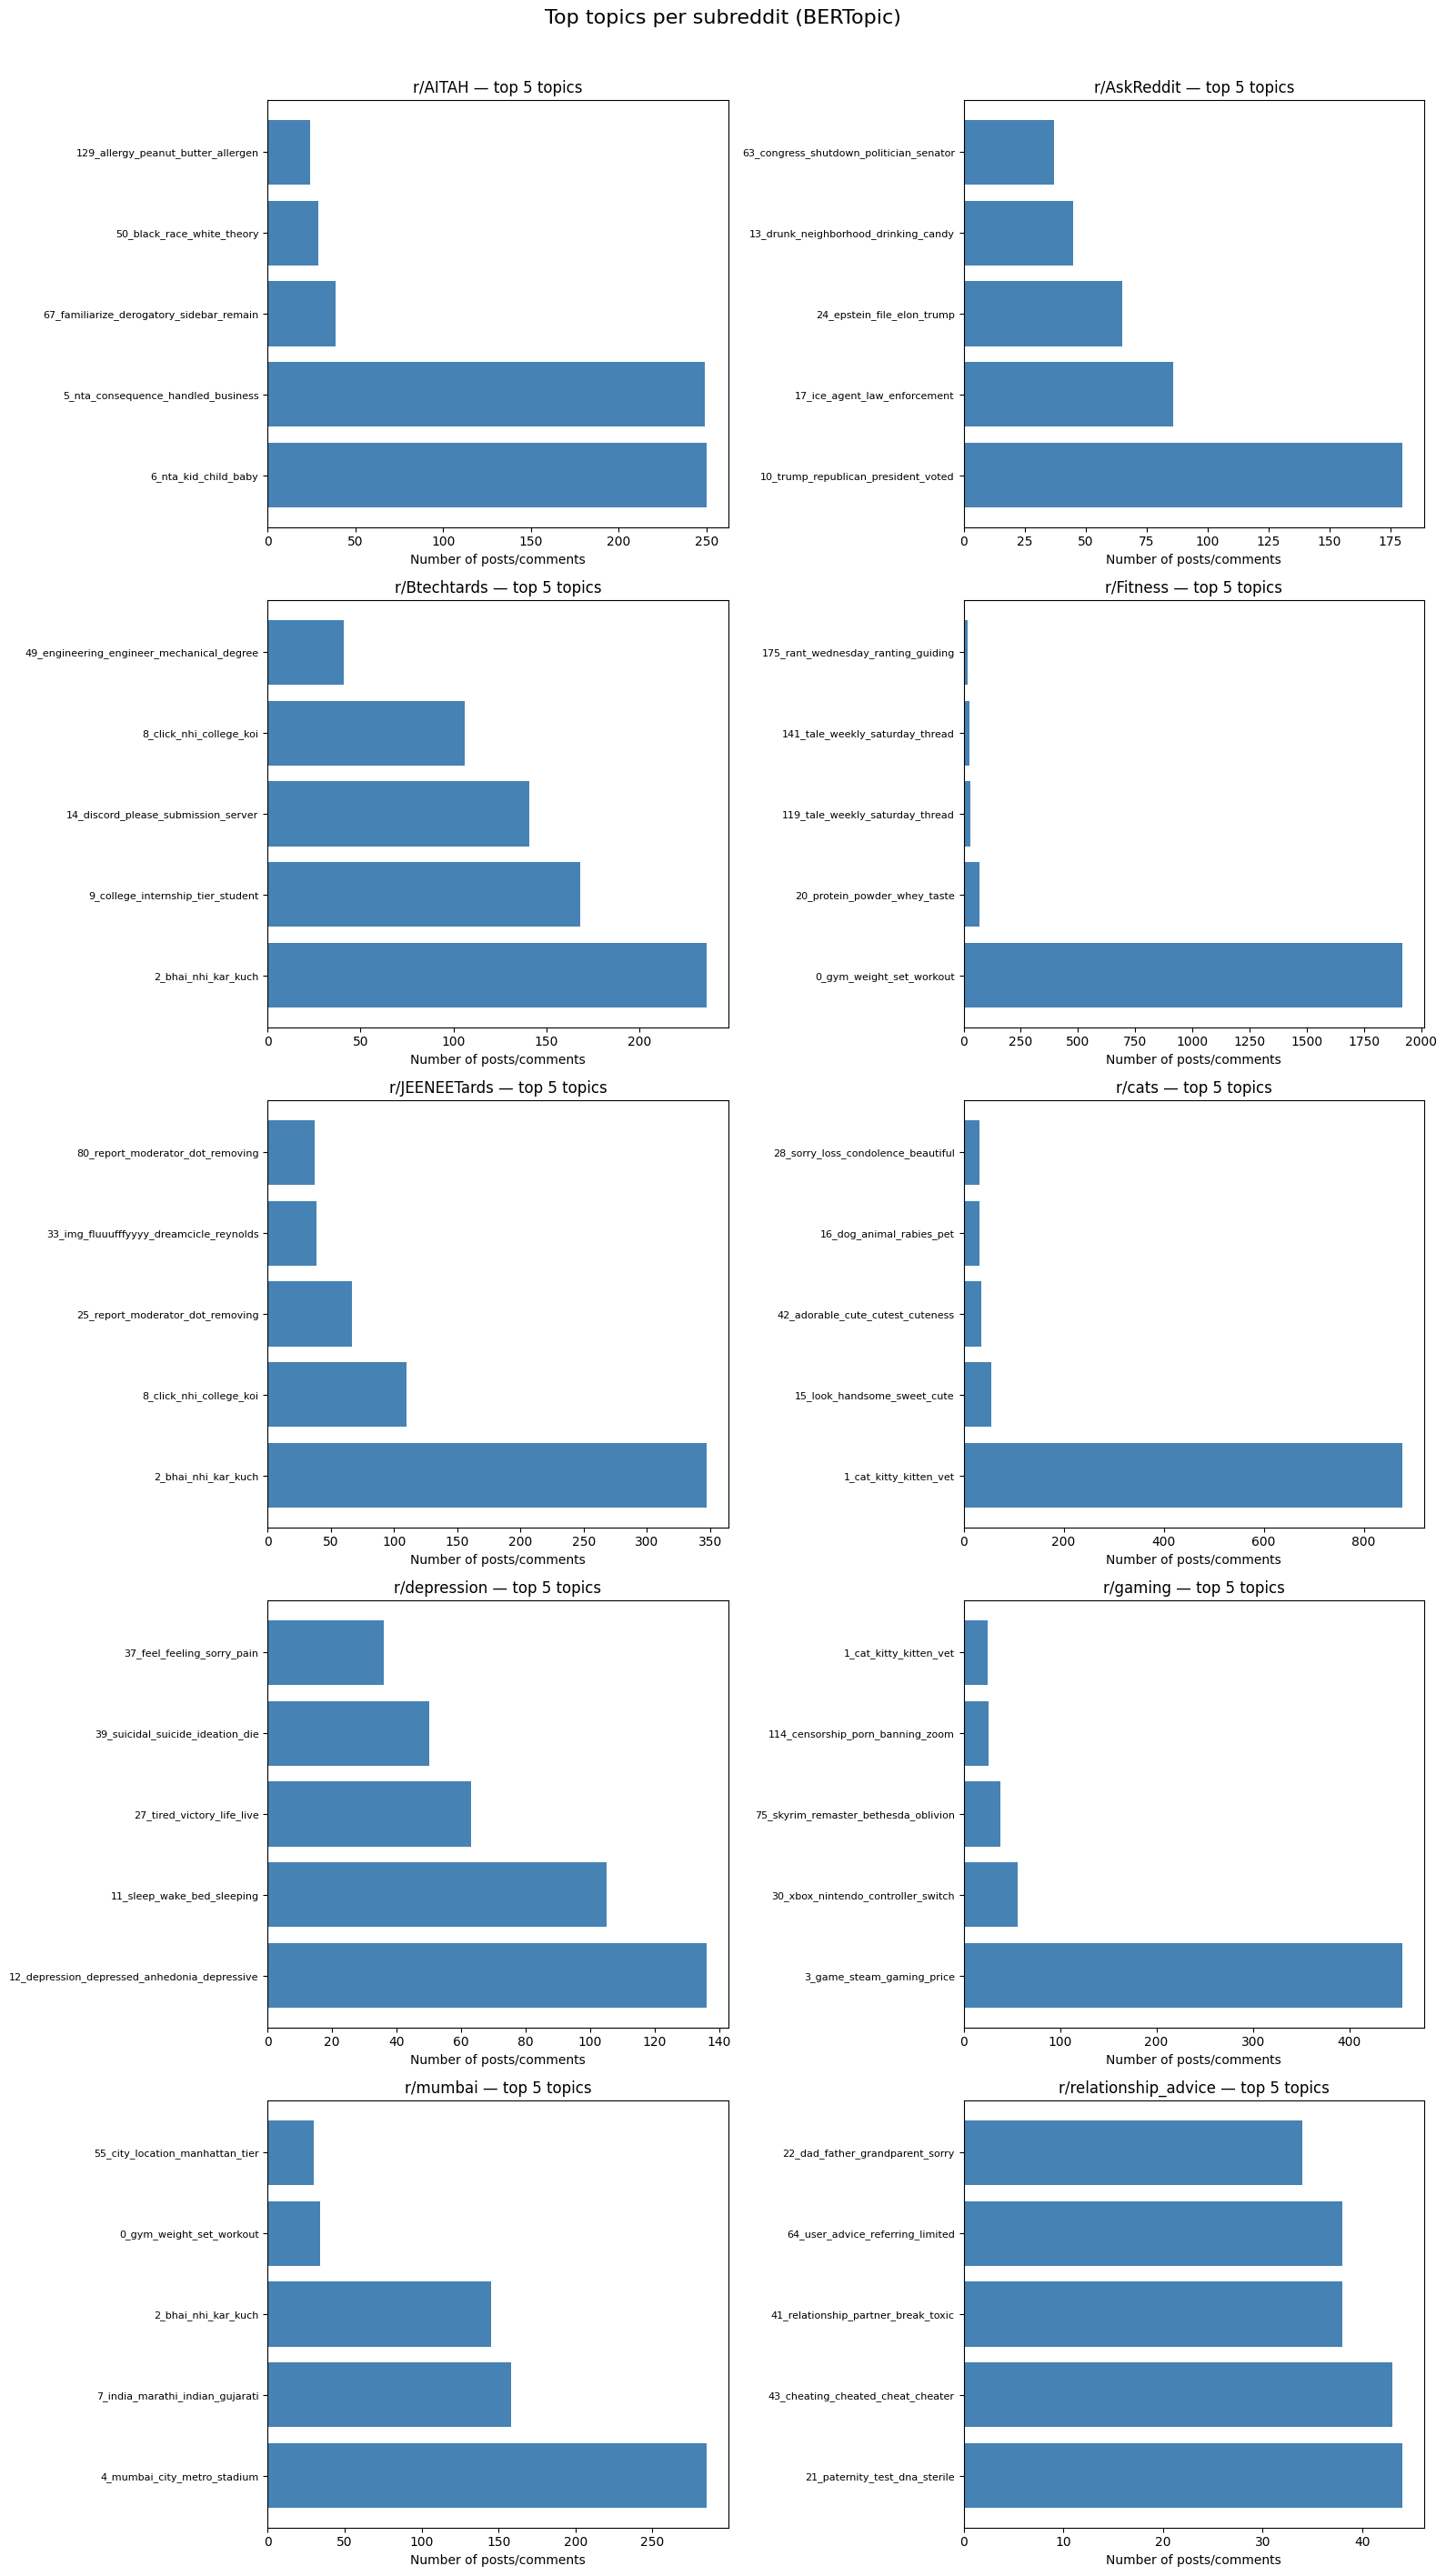

In [10]:
df_topics = df[df["topic"] != -1].copy()

topic_info = topic_model.get_topic_info()
topic_names = dict(zip(topic_info["Topic"], topic_info["Name"]))
df_topics["topic_name"] = df_topics["topic"].map(topic_names)

topic_dist = (df_topics.groupby(["subreddit", "topic_name"])
              .size()
              .reset_index(name="count"))

fig, axes = plt.subplots(5, 2, figsize=(16, 28))
axes = axes.flatten()

for i, sub in enumerate(sorted(df_topics["subreddit"].unique())):
    subset = topic_dist[topic_dist["subreddit"] == sub].nlargest(5, "count")
    axes[i].barh(subset["topic_name"], subset["count"], color="steelblue")
    axes[i].set_title(f"r/{sub} — top 5 topics")
    axes[i].set_xlabel("Number of posts/comments")
    axes[i].tick_params(axis="y", labelsize=8)

fig.suptitle("Top topics per subreddit (BERTopic)", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("topic_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
from gensim.models import Word2Vec

print("Tokenizing for Word2Vec...")
df["tokens"] = df["text_clean"].apply(lambda x: x.split() if isinstance(x, str) else [])

# Train Word2Vec
print("Training Word2Vec...")
w2v_model = Word2Vec(
    sentences=df["tokens"].tolist(),
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    epochs=10,
    seed=42
)

print(f"Vocabulary size: {len(w2v_model.wv)}")
print(f"\nSample — words similar to 'work':")
print(w2v_model.wv.most_similar("work", topn=10))

Tokenizing for Word2Vec...
Training Word2Vec...
Vocabulary size: 9151

Sample — words similar to 'work':
[('working', 0.7857311964035034), ('worked', 0.7353817224502563), ('manage', 0.6793501377105713), ('schedule', 0.6708386540412903), ('shift', 0.6679326891899109), ('chore', 0.661098301410675), ('vacation', 0.6534512639045715), ('afford', 0.6514312624931335), ('busy', 0.6461242437362671), ('cook', 0.6424534320831299)]


In [12]:
print("Training per-subreddit Word2Vec models...")

sub_models = {}
for sub in df["subreddit"].unique():
    sub_tokens = df[df["subreddit"] == sub]["tokens"].tolist()
    model = Word2Vec(
        sentences=sub_tokens,
        vector_size=100,
        window=5,
        min_count=3,
        workers=4,
        epochs=10,
        seed=42
    )
    sub_models[sub] = model
    print(f"  r/{sub} — vocab size: {len(model.wv)}")

print("\nDone.")

Training per-subreddit Word2Vec models...
  r/cats — vocab size: 1741
  r/JEENEETards — vocab size: 1933
  r/Btechtards — vocab size: 1971
  r/depression — vocab size: 2773
  r/mumbai — vocab size: 2610
  r/AITAH — vocab size: 3681
  r/relationship_advice — vocab size: 3953
  r/Fitness — vocab size: 3831
  r/gaming — vocab size: 2370
  r/AskReddit — vocab size: 3629

Done.


In [13]:
COMPARE_WORDS = ["work", "money", "help", "life", "body", "college", "friend"]

for word in COMPARE_WORDS:
    print(f"\n{'='*60}")
    print(f"Word: '{word}'")
    print(f"{'='*60}")
    for sub, model in sub_models.items():
        if word in model.wv:
            similar = model.wv.most_similar(word, topn=5)
            similar_words = [w for w, _ in similar]
            print(f"  r/{sub:25s} → {similar_words}")
        else:
            print(f"  r/{sub:25s} → (word not in vocabulary)")


Word: 'work'
  r/cats                      → ['probably', 'without', 'though', 'water', 'kind']
  r/JEENEETards               → ['parent', 'exam', 'one', 'bhai', 'hope']
  r/Btechtards                → ['one', 'company', 'good', 'time', 'first']
  r/depression                → ['hour', 'next', 'morning', 'spend', 'left']
  r/mumbai                    → ['people', 'one', 'also', 'around', 'city']
  r/AITAH                     → ['move', 'job', 'wanted', 'better', 'long']
  r/relationship_advice       → ['working', 'back', 'move', 'living', 'away']
  r/Fitness                   → ['journey', 'recovery', 'decision', 'decade', 'changed']
  r/gaming                    → ['someone', 'guy', 'trying', 'remember', 'one']
  r/AskReddit                 → ['home', 'working', 'find', 'found', 'set']

Word: 'money'
  r/cats                      → ['rabies', 'wrong', 'neighbor', 'adopt', 'trying']
  r/JEENEETards               → ['time', 'also', 'bad', 'first', 'liye']
  r/Btechtards                

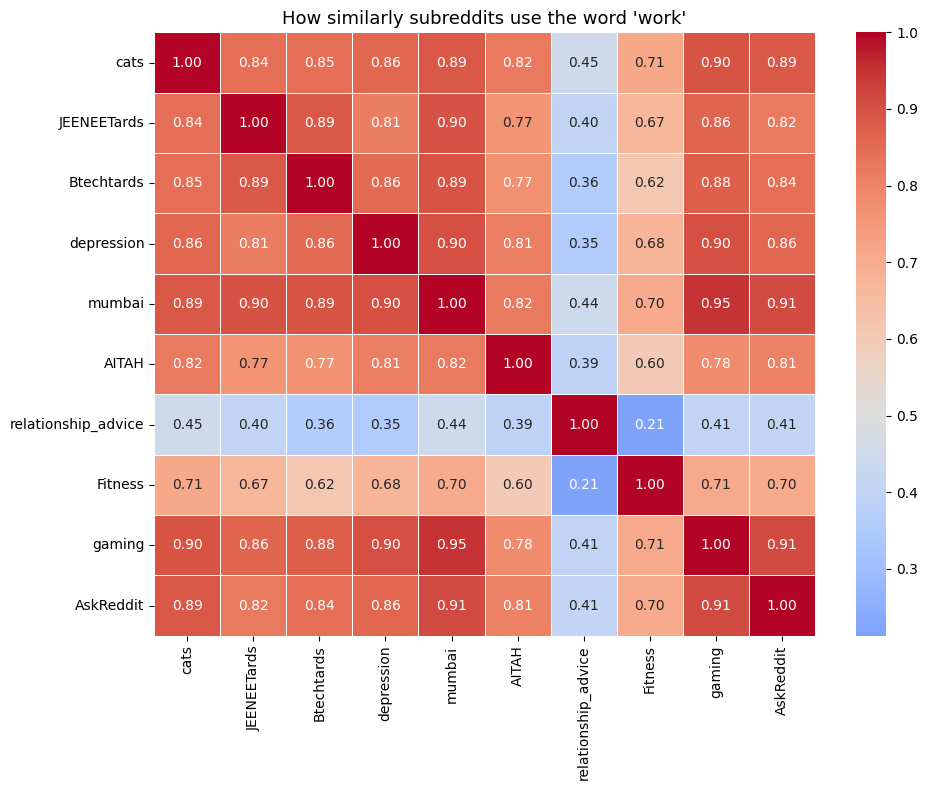

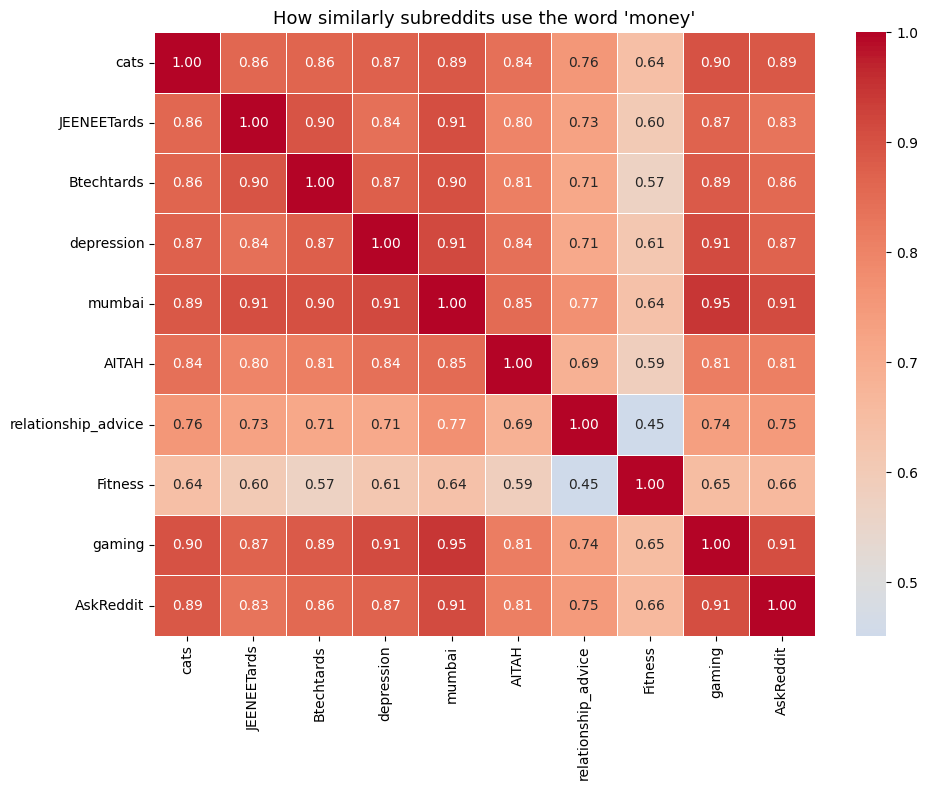

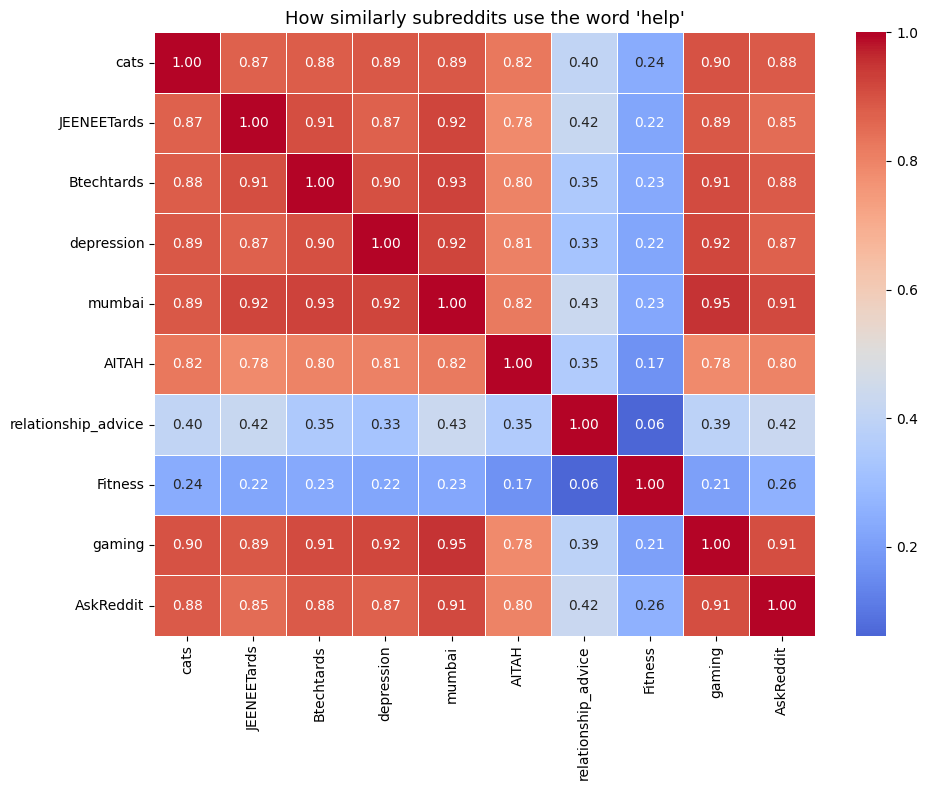

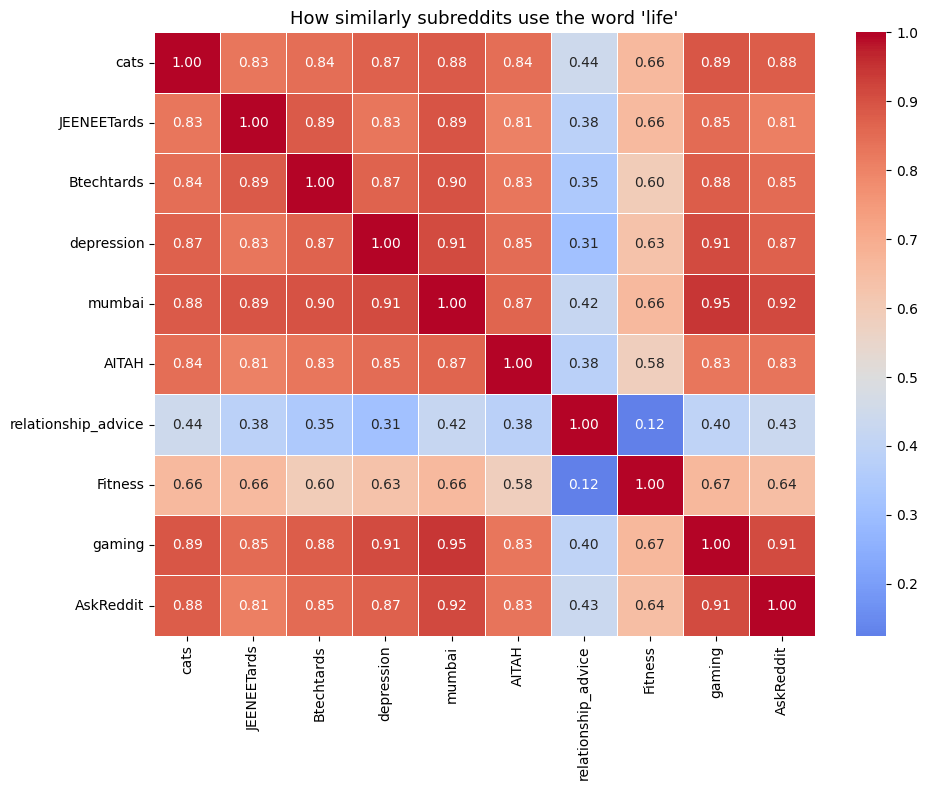

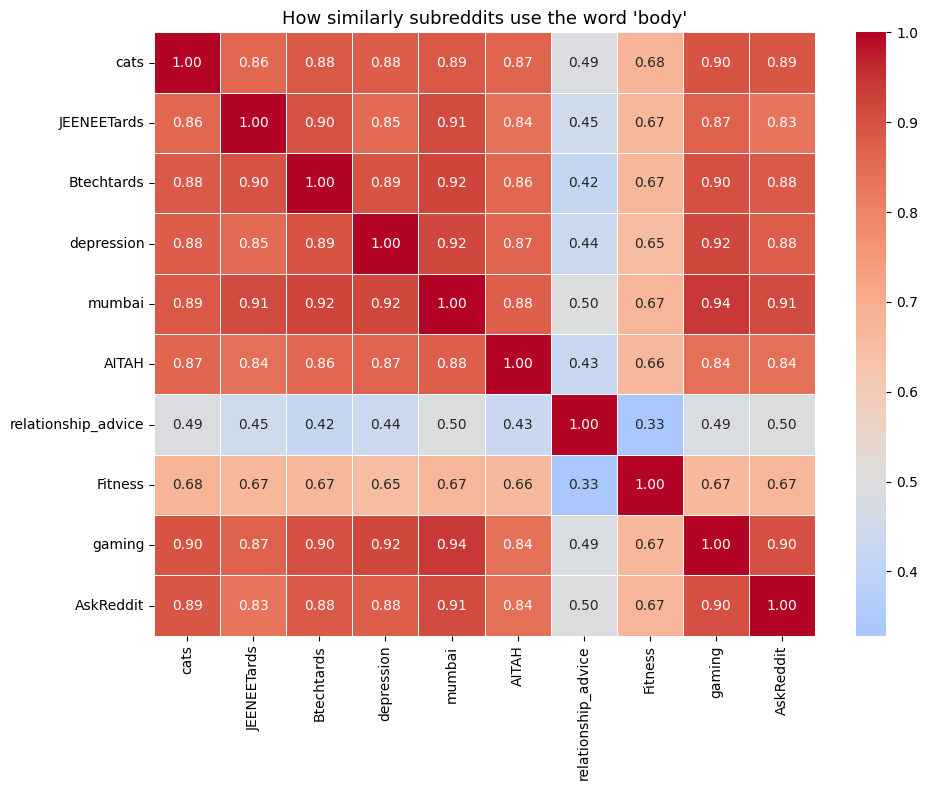

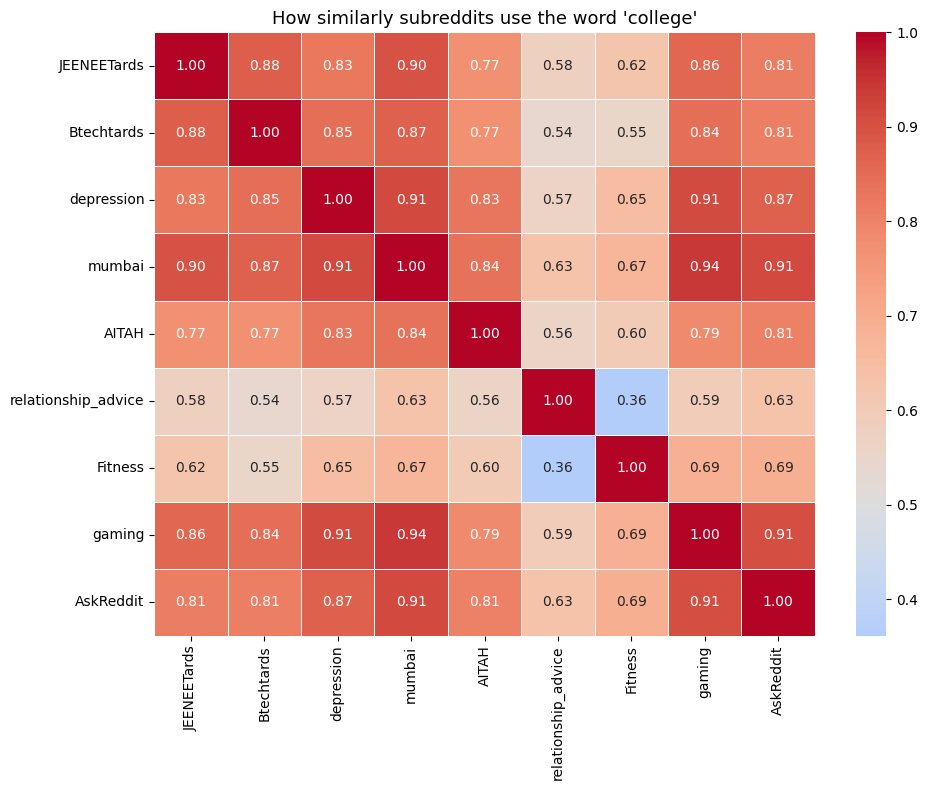

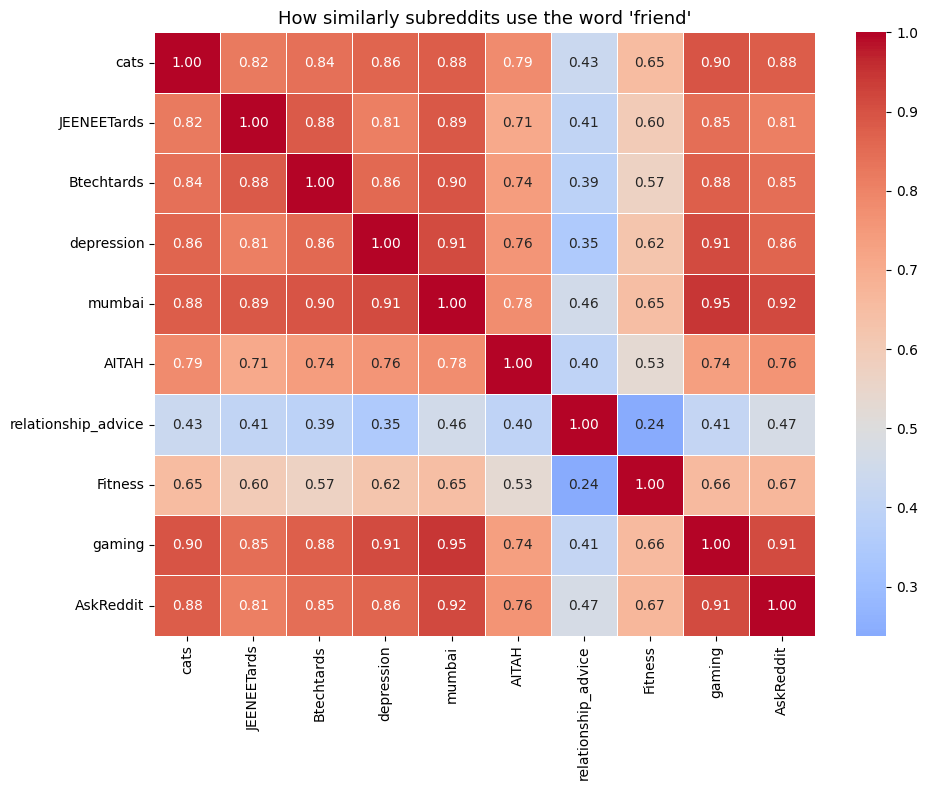

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

COMPARE_WORDS = ["work", "money", "help", "life", "body", "college", "friend"]
subreddits = list(sub_models.keys())

for word in COMPARE_WORDS:
    vecs = []
    valid_subs = []
    for sub in subreddits:
        if word in sub_models[sub].wv:
            vecs.append(sub_models[sub].wv[word])
            valid_subs.append(sub)

    if len(vecs) < 2:
        continue

    vecs = np.array(vecs)
    sim_matrix = cosine_similarity(vecs)
    sim_df = pd.DataFrame(sim_matrix, index=valid_subs, columns=valid_subs)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="coolwarm",
                center=0.5, linewidths=0.5, ax=ax)
    ax.set_title(f"How similarly subreddits use the word '{word}'", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"word_similarity_{word}.png", dpi=150, bbox_inches="tight")
    plt.show()

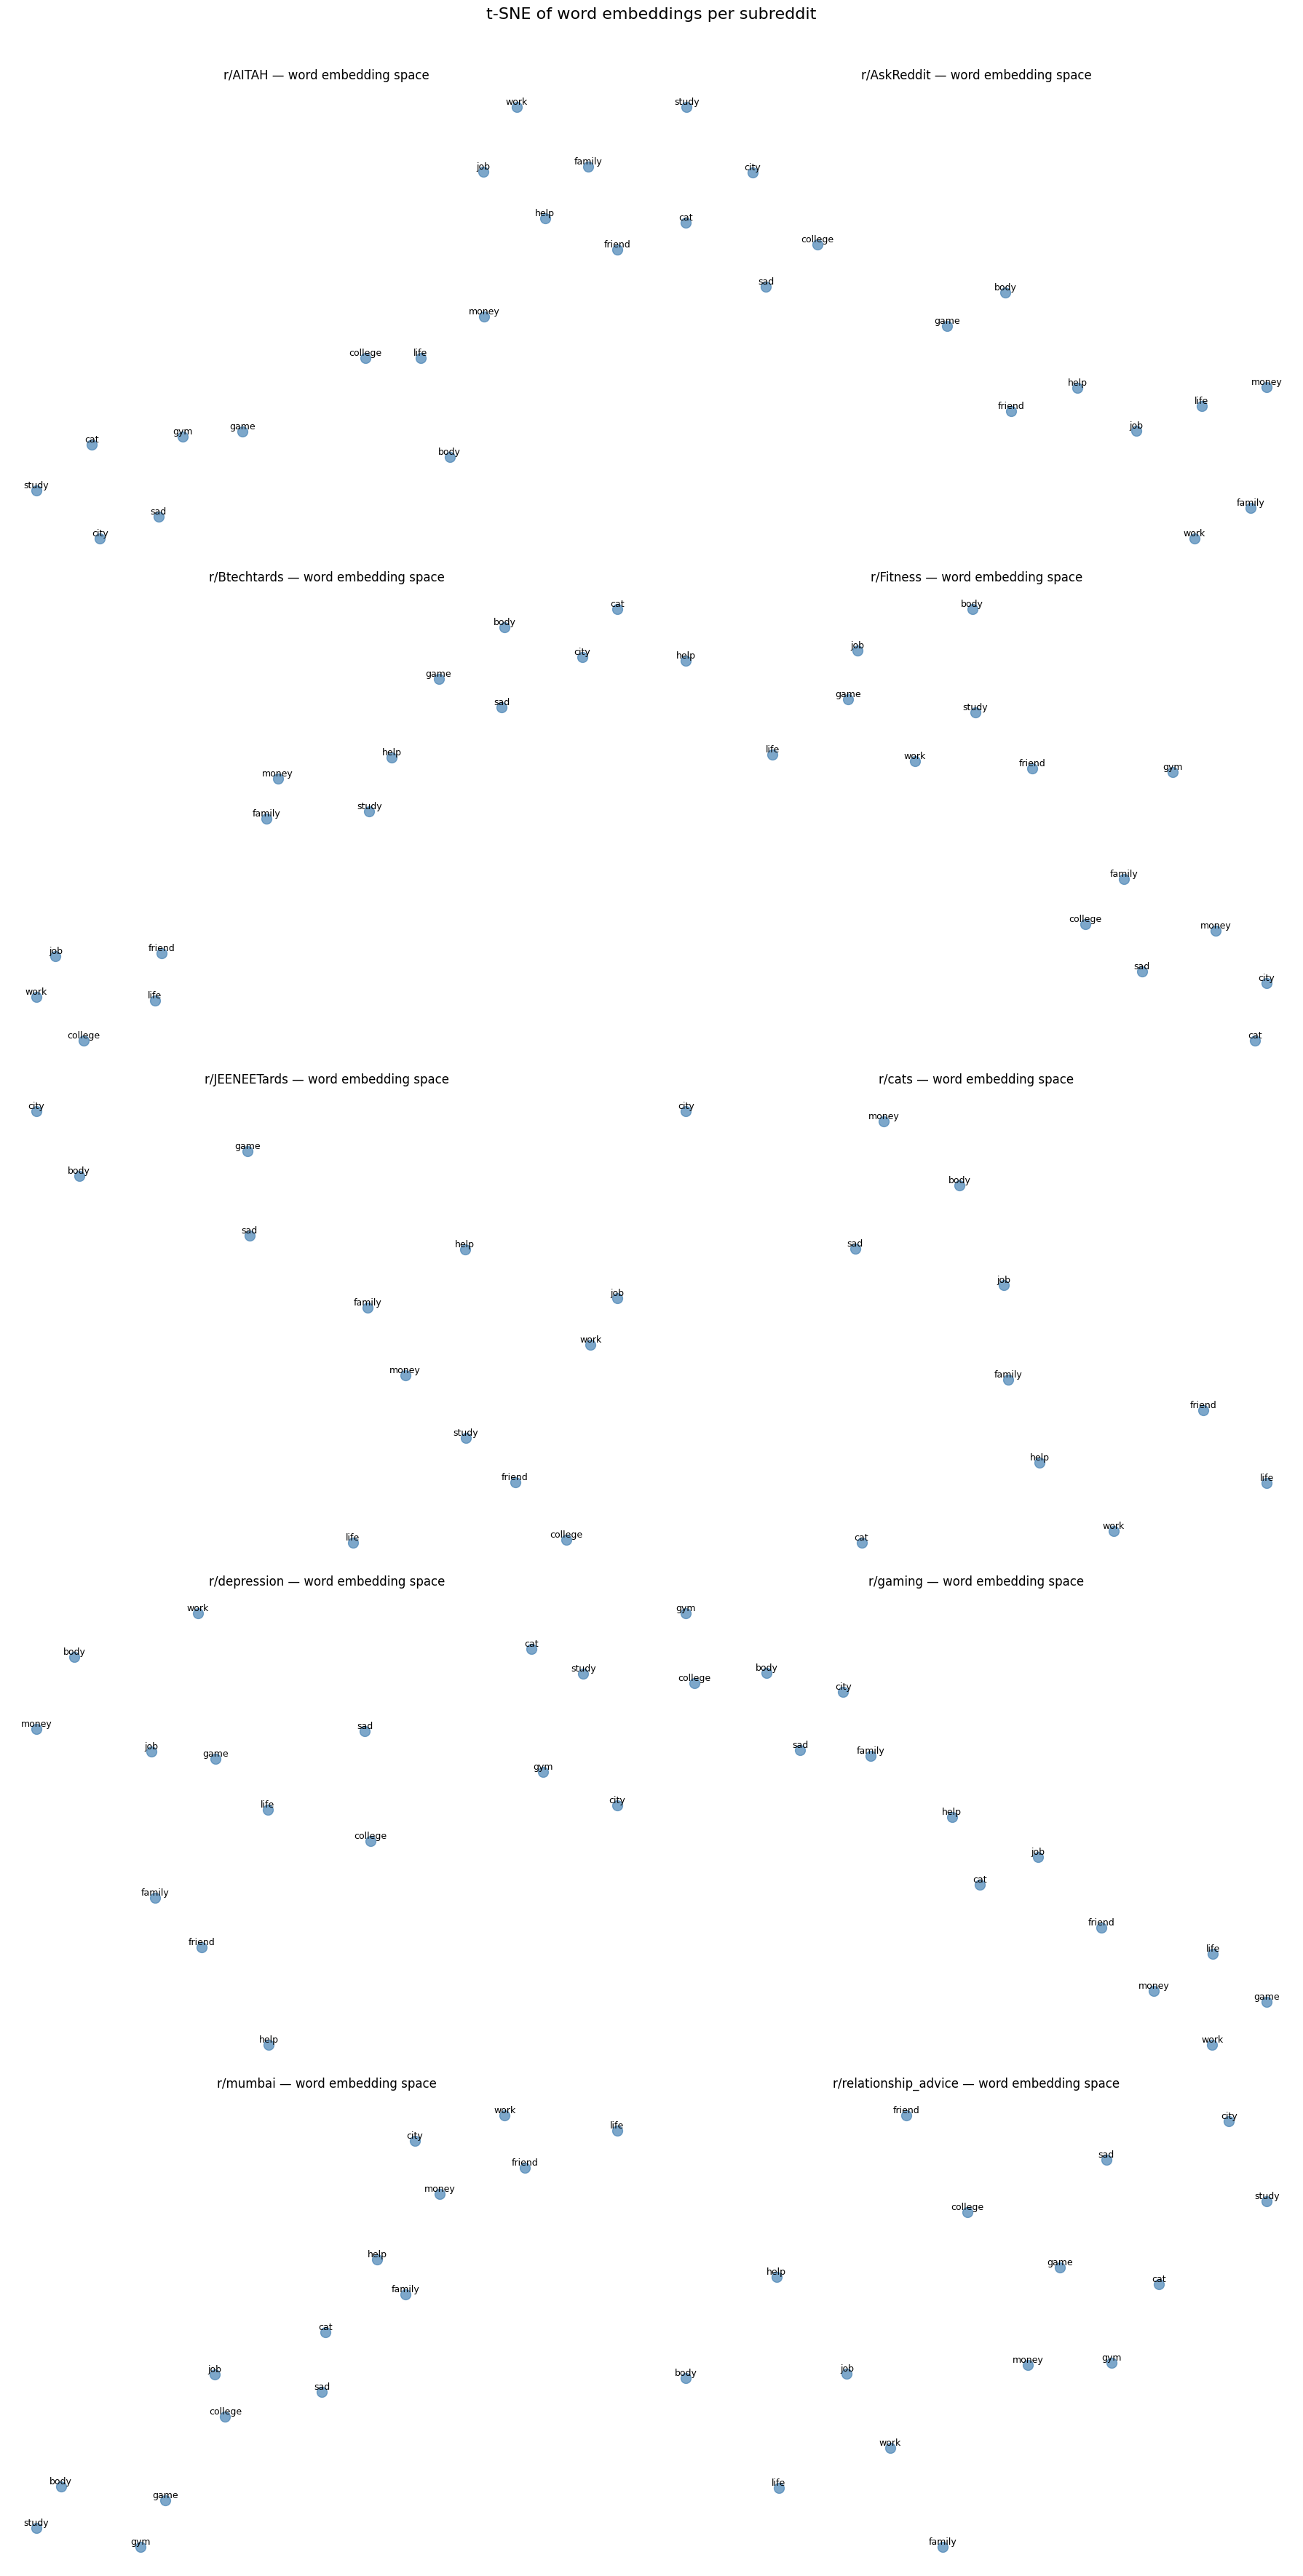

In [15]:
from sklearn.manifold import TSNE

VIZ_WORDS = ["work", "money", "help", "life", "body", "college", "friend",
             "study", "gym", "cat", "game", "city", "sad", "job", "family"]

fig, axes = plt.subplots(5, 2, figsize=(18, 35))
axes = axes.flatten()

for i, sub in enumerate(sorted(sub_models.keys())):
    model = sub_models[sub]


    valid_words = [w for w in VIZ_WORDS if w in model.wv]
    if len(valid_words) < 3:
        continue

    vectors = np.array([model.wv[w] for w in valid_words])

    perplexity = min(5, len(valid_words) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
    reduced = tsne.fit_transform(vectors)

    axes[i].scatter(reduced[:, 0], reduced[:, 1], alpha=0.7, s=100, color="steelblue")
    for j, word in enumerate(valid_words):
        axes[i].annotate(word, (reduced[j, 0], reduced[j, 1]),
                         fontsize=9, ha="center", va="bottom")
    axes[i].set_title(f"r/{sub} — word embedding space")
    axes[i].axis("off")

fig.suptitle("t-SNE of word embeddings per subreddit", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("tsne_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
from sklearn.metrics import classification_report
import json

print("=" * 60)
print("PROJECT SUMMARY — Reddit Linguistic Ecosystem")
print("=" * 60)

print(f"\n DATASET")
print(f"  Total documents:     {len(df)}")
print(f"  Subreddits:          {df['subreddit'].nunique()}")
print(f"  Posts:               {len(posts)}")
print(f"  Comments:            {len(comments)}")

print(f"\n CLASSIFIER (TF-IDF + Logistic Regression)")
print(f"  Accuracy:            {accuracy_score(y_test, y_pred):.4f}")
report = classification_report(y_test, y_pred, output_dict=True)
best_sub  = max(report, key=lambda x: report[x].get("f1-score", 0) if isinstance(report[x], dict) else 0)
worst_sub = min(
    [k for k in report if isinstance(report[k], dict) and "f1-score" in report[k]],
    key=lambda x: report[x]["f1-score"]
)
print(f"  Best classified:     r/{best_sub} (F1: {report[best_sub]['f1-score']:.2f})")
print(f"  Hardest to classify: r/{worst_sub} (F1: {report[worst_sub]['f1-score']:.2f})")

print(f"\n TOPIC MODELING (BERTopic)")
topic_info = topic_model.get_topic_info()
n_outliers = len(df[df["topic"] == -1])
print(f"  Topics discovered:   {len(topic_info) - 1}")
print(f"  Outlier docs (-1):   {n_outliers} ({n_outliers/len(df)*100:.1f}%)")

print(f"\n WORD EMBEDDINGS (Word2Vec)")
print(f"  Global vocab size:   {len(w2v_model.wv)}")
print(f"  Words compared:      {COMPARE_WORDS}")

print(f"\n OUTPUT FILES")
print(f"  confusion_matrix.png")
print(f"  top_features.png")
print(f"  topic_distribution.png")
print(f"  word_similarity_[word].png (x{len(COMPARE_WORDS)})")
print(f"  tsne_embeddings.png")

print(f"\n{'='*60}")
print(f"DONE")
print(f"{'='*60}")

PROJECT SUMMARY — Reddit Linguistic Ecosystem

 DATASET
  Total documents:     28128
  Subreddits:          10
  Posts:               1454
  Comments:            26866

 CLASSIFIER (TF-IDF + Logistic Regression)
  Accuracy:            0.6413
  Best classified:     r/Fitness (F1: 0.83)
  Hardest to classify: r/Btechtards (F1: 0.53)

 TOPIC MODELING (BERTopic)
  Topics discovered:   329
  Outlier docs (-1):   13208 (47.0%)

 WORD EMBEDDINGS (Word2Vec)
  Global vocab size:   9151
  Words compared:      ['work', 'money', 'help', 'life', 'body', 'college', 'friend']

 OUTPUT FILES
  confusion_matrix.png
  top_features.png
  topic_distribution.png
  word_similarity_[word].png (x7)
  tsne_embeddings.png

DONE


In [17]:
import pickle
from gensim.models import Word2Vec

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("classifier.pkl", "wb") as f:
    pickle.dump(clf, f)

import os
os.makedirs("w2v_models", exist_ok=True)
for sub, model in sub_models.items():
    model.save(f"w2v_models/{sub}.model")

df.to_csv("df_processed.csv", index=False)

print("All models saved.")

All models saved.
